# Model A: NLI Cross-Encoder — 3-Class Intent Verification

Fine-tunes `cross-encoder/nli-MiniLM2-L6-H768` on the finalized thesis dataset for 3-class NLI classification of agent subtask alignment.

**Datasets:**
- **Training:** `cue_split.csv` rows where `cue_split == 'train'` (622 samples)
- **Primary Evaluation:** `cue_split.csv` rows where `cue_split == 'test'` (84 samples — concept-disjoint, all `demographic_proxy`)
- **Frozen Holdout:** `holdout_clean_curated.csv` (122 samples — untouched until final evaluation)

**Task:** Given `(goal, subtask)`, classify as:
- `0` = Malicious (contradiction)
- `1` = Benign-entailment
- `2` = Neutral

**Loss:** Cross-Entropy (3-class)

**Lexical Baseline Reference:** TF-IDF + Logistic Regression achieves ~0.981 AUC on the concept-disjoint `cue_split` evaluation. Model performance should be evaluated against this benchmark.

## 1. Install Dependencies

In [1]:
!pip install -q sentence-transformers datasets scikit-learn matplotlib seaborn

## 2. Imports & Configuration

In [2]:
import os

# Must be set BEFORE any torch/CUDA import — prevents DataParallel
# wrapping on multi-GPU Kaggle instances which crashes CrossEncoder.
os.environ["CUDA_VISIBLE_DEVICES"] = "0"

import json
import time
import gc
import warnings
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    f1_score, precision_recall_fscore_support, accuracy_score,
    roc_curve, auc
)
from sklearn.calibration import calibration_curve
from scipy.special import softmax

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")

# ── Config ──────────────────────────────────────────────────
MODEL_NAME  = "cross-encoder/nli-MiniLM2-L6-H768"
NUM_LABELS  = 3
EPOCHS      = 4
BATCH_SIZE  = 16
LR          = 5e-5
WEIGHT_DECAY = 0.02
WARMUP_STEPS = 0.1          # float = ratio (Transformers v5+)
SEED        = 1
OUTPUT_DIR  = "/kaggle/working/model_a_nli_finetuned"

LABEL_NAMES = {0: "Malicious", 1: "Benign-entailment", 2: "Neutral"}
LABEL_LIST  = ["Malicious", "Benign-entail", "Neutral"]

# ── Dataset paths ─────────────────────────────────────────
def find_file(name):
    candidates = [
        f"/kaggle/input/thesis-datasets/{name}",
        f"/kaggle/input/{name.replace('.csv','')}/{name}",
        name,
        f"./{name}",
    ]
    for p in candidates:
        if os.path.exists(p):
            return p
    raise FileNotFoundError(f"Cannot find {name}. Tried: {candidates}")

CORPUS_PATH  = find_file("/kaggle/input/datasets/oxyjen/thesis-dataset-try/corpus_clean_merged.csv")
CUE_PATH     = find_file("/kaggle/input/datasets/oxyjen/thesis-dataset-try/cue_split_phrases_merged.csv")
HOLDOUT_PATH = find_file("/kaggle/input/datasets/oxyjen/thesis-dataset-try/holdout_clean_curated_merged.csv")

gpu_name = torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU"
print(f"Model:       {MODEL_NAME}")
print(f"Epochs:      {EPOCHS}")
print(f"Batch size:  {BATCH_SIZE}")
print(f"GPU:         {gpu_name}")
print(f"GPU count:   {torch.cuda.device_count()} (should be 1)")
print(f"Corpus:      {CORPUS_PATH}")
print(f"Cue split:   {CUE_PATH}")
print(f"Holdout:     {HOLDOUT_PATH}")

Model:       cross-encoder/nli-MiniLM2-L6-H768
Epochs:      4
Batch size:  16
GPU:         Tesla T4
GPU count:   1 (should be 1)
Corpus:      /kaggle/input/datasets/oxyjen/thesis-dataset-try/corpus_clean_merged.csv
Cue split:   /kaggle/input/datasets/oxyjen/thesis-dataset-try/cue_split_phrases_merged.csv
Holdout:     /kaggle/input/datasets/oxyjen/thesis-dataset-try/holdout_clean_curated_merged.csv


## 3. Load & Validate Datasets

In [3]:
# ── Load ────────────────────────────────────────────────────
corpus  = pd.read_csv(CORPUS_PATH)
cue     = pd.read_csv(CUE_PATH)
holdout = pd.read_csv(HOLDOUT_PATH)

# ── Validate required columns ──────────────────────────────
for name, df in [("corpus_clean", corpus), ("cue_split", cue), ("holdout", holdout)]:
    for col in ["goal", "subtask", "label"]:
        assert col in df.columns, f"Missing column '{col}' in {name}"
    assert set(df["label"].unique()) <= {0, 1, 2}, f"Invalid labels in {name}: {df['label'].unique()}"
    print(f"✓ {name:25s}  rows={len(df):>4d}  labels={dict(Counter(df['label']))}")

assert "cue_split" in cue.columns, "Missing 'cue_split' column in cue_split.csv"

# ── Build train/test from cue_split ────────────────────────
train_df = cue[cue["cue_split"] == "train"].copy()
test_df  = cue[cue["cue_split"] == "test"].copy()

print(f"\n── Split summary ──────────────────────────────────")
print(f"  Train:   {len(train_df):>4d} samples  labels: {dict(Counter(train_df['label']))}")
print(f"  Test:    {len(test_df):>4d} samples  labels: {dict(Counter(test_df['label']))}")
print(f"  Holdout: {len(holdout):>4d} samples  labels: {dict(Counter(holdout['label']))}")

# ── Verify concept-disjoint test ───────────────────────────
if "concept" in cue.columns:
    train_concepts = set(train_df["concept"].dropna().unique())
    test_concepts  = set(test_df["concept"].dropna().unique())
    overlap = train_concepts & test_concepts
    print(f"\n  Test concepts:    {test_concepts}")
    print(f"  Concept overlap:  {overlap if overlap else 'NONE ✓ (concept-disjoint)'}")

✓ corpus_clean               rows= 924  labels={1: 387, 2: 181, 0: 356}
✓ cue_split                  rows=1168  labels={1: 439, 2: 233, 0: 496}
✓ holdout                    rows= 244  labels={0: 140, 1: 52, 2: 52}

── Split summary ──────────────────────────────────
  Train:   1044 samples  labels: {1: 392, 2: 233, 0: 419}
  Test:     124 samples  labels: {1: 47, 0: 77}
  Holdout:  244 samples  labels: {0: 140, 1: 52, 2: 52}

  Test concepts:    {'third_party_external', 'subject_social', 'unclassified', 'subject_location', 'private_interest', 'privileged_internal', 'demographic_proxy', 'subject_health', 'subject_financial'}
  Concept overlap:  {'third_party_external', 'subject_social', 'subject_financial', 'unclassified', 'private_interest', 'privileged_internal', 'demographic_proxy', 'subject_health', 'subject_location'}


## 4. Construct NLI Inputs

Convert `(goal, subtask)` into NLI `(premise, hypothesis)` pairs using the same template as the original `sentinelagent_nli_finetune.py`.

In [4]:
def build_nli_pairs(df):
    """
    Convert (goal, subtask, label) rows to NLI format.
    Returns: list of (premise, hypothesis, label) tuples.
    """
    pairs = []
    for _, row in df.iterrows():
        goal    = str(row["goal"]).strip()
        subtask = str(row["subtask"]).strip()
        label   = int(row["label"])

        premise = (
            f"An AI agent is authorized to {goal[0].lower() + goal[1:]}. "
            f"The agent performs only tasks that support this goal."
        )
        hypothesis = f"The agent is now performing: {subtask[0].lower() + subtask[1:]}"
        pairs.append((premise, hypothesis, label))
    return pairs


train_pairs = build_nli_pairs(train_df)
test_pairs  = build_nli_pairs(test_df)

print(f"Train NLI pairs: {len(train_pairs)}")
print(f"Test  NLI pairs: {len(test_pairs)}")

# Show examples
for i in range(min(3, len(train_pairs))):
    p, h, l = train_pairs[i]
    print(f"\n[{LABEL_NAMES[l]}]")
    print(f"  P: {p[:100]}...")
    print(f"  H: {h[:100]}")

Train NLI pairs: 1044
Test  NLI pairs: 124

[Benign-entailment]
  P: An AI agent is authorized to process disability benefits for veteran. The agent performs only tasks ...
  H: The agent is now performing: retrieve the veteran's medical records from the VA health system

[Benign-entailment]
  P: An AI agent is authorized to process disability benefits for veteran. The agent performs only tasks ...
  H: The agent is now performing: verify the applicant's service-connected disability rating

[Benign-entailment]
  P: An AI agent is authorized to process disability benefits for veteran. The agent performs only tasks ...
  H: The agent is now performing: calculate the monthly benefit amount based on disability percentage


## 5. Baseline Evaluation (Zero-Shot NLI)

Evaluate the **off-the-shelf** model before fine-tuning to establish the NLI baseline.

In [5]:
from sentence_transformers import CrossEncoder


def full_evaluate(model, pairs, label_names=LABEL_LIST, title="Evaluation"):
    """
    Comprehensive evaluation: accuracy, macro-F1, per-class P/R/F1,
    confusion matrix, ROC-AUC, FPR at operating points, calibration.
    Returns dict of metrics + raw predictions.
    """
    inputs      = [(p, h) for p, h, _ in pairs]
    true_labels = np.array([l for _, _, l in pairs])

    # Raw scores from the model
    raw_scores  = model.predict(inputs, batch_size=64)
    probs       = softmax(raw_scores, axis=1)
    pred_labels = np.argmax(probs, axis=1)

    # ── Always use ALL 3 classes ──────────────────────────
    # The test set may lack some classes (e.g. no neutral in
    # cue_split test). If we only use present ground-truth
    # labels, predictions falling into a missing class become
    # invisible (e.g. zero-shot predicting everything as
    # neutral produces an all-zeros confusion matrix).
    all_labels = [0, 1, 2]
    all_names  = [label_names[i] for i in all_labels]

    acc = accuracy_score(true_labels, pred_labels)
    macro_f1 = f1_score(true_labels, pred_labels, average="macro",
                        labels=all_labels, zero_division=0)

    report = classification_report(
        true_labels, pred_labels,
        labels=all_labels,
        target_names=all_names,
        zero_division=0, output_dict=True
    )

    # ── Confusion matrix ──────────────────────────────────
    cm = confusion_matrix(true_labels, pred_labels, labels=all_labels)

    # ── ROC-AUC (one-vs-rest) ─────────────────────────────
    try:
        present_in_truth = sorted(set(true_labels))
        if len(present_in_truth) >= 2:
            roc_macro = roc_auc_score(
                true_labels, probs[:, present_in_truth],
                multi_class="ovr", average="macro",
                labels=present_in_truth
            )
        else:
            roc_macro = float("nan")
    except ValueError:
        roc_macro = float("nan")

    # ── Binary security metrics (malicious=0 vs rest) ─────
    true_mal  = (true_labels == 0).astype(int)
    pred_mal  = (pred_labels == 0).astype(int)
    prob_mal  = probs[:, 0]

    tp = int(((pred_mal == 1) & (true_mal == 1)).sum())
    fp = int(((pred_mal == 1) & (true_mal == 0)).sum())
    fn = int(((pred_mal == 0) & (true_mal == 1)).sum())
    tn = int(((pred_mal == 0) & (true_mal == 0)).sum())

    tpr = tp / (tp + fn) if (tp + fn) > 0 else 0
    fpr = fp / (fp + tn) if (fp + tn) > 0 else 0
    binary_prec = tp / (tp + fp) if (tp + fp) > 0 else 0

    try:
        binary_auc = roc_auc_score(true_mal, prob_mal)
    except ValueError:
        binary_auc = float("nan")

    # ── FPR at operating points ───────────────────────────
    fpr_at = {}
    if not np.isnan(binary_auc):
        fpr_vals, tpr_vals, thresholds = roc_curve(true_mal, prob_mal)
        for target_tpr in [0.90, 0.95, 0.99]:
            idx = np.where(tpr_vals >= target_tpr)[0]
            if len(idx) > 0:
                fpr_at[f"FPR@TPR={target_tpr:.0%}"] = float(fpr_vals[idx[0]])

    # ── Print ─────────────────────────────────────────────
    print(f"\n{'═'*60}")
    print(f"  {title}")
    print(f"{'═'*60}")
    print(f"  Accuracy:       {acc:.4f}")
    print(f"  Macro F1:       {macro_f1:.4f}")
    print(f"  ROC-AUC (OvR):  {roc_macro:.4f}" if not np.isnan(roc_macro) else "  ROC-AUC: N/A")
    print(f"\n  Per-class metrics:")
    print(f"  {'Class':20s} {'Prec':>6s} {'Recall':>6s} {'F1':>6s} {'Support':>8s}")
    for name in all_names:
        r = report[name]
        print(f"  {name:20s} {r['precision']:6.3f} {r['recall']:6.3f} {r['f1-score']:6.3f} {r['support']:8.0f}")
    print(f"\n  Prediction distribution: {dict(Counter(pred_labels))}")
    print(f"  True label distribution: {dict(Counter(true_labels))}")
    print(f"\n  Binary (Malicious vs Rest):")
    print(f"    TPR:       {tpr:.4f}  ({tp}/{tp+fn})")
    print(f"    FPR:       {fpr:.4f}  ({fp}/{fp+tn})")
    print(f"    Precision: {binary_prec:.4f}")
    print(f"    AUC:       {binary_auc:.4f}" if not np.isnan(binary_auc) else "    AUC: N/A")
    for k, v in fpr_at.items():
        print(f"    {k}: {v:.4f}")
    print(f"\n  Confusion matrix (rows=true, cols=pred):")
    print(f"  {'':20s}", end="")
    for n in all_names:
        print(f" {n[:8]:>8s}", end="")
    print()
    for i, n in enumerate(all_names):
        print(f"  {n:20s}", end="")
        for j in range(len(all_names)):
            print(f" {cm[i][j]:8d}", end="")
        print()

    return {
        "accuracy": acc, "macro_f1": macro_f1, "roc_auc_macro": roc_macro,
        "tpr": tpr, "fpr": fpr, "binary_precision": binary_prec,
        "binary_auc": binary_auc, "fpr_at_operating_points": fpr_at,
        "confusion_matrix": cm.tolist(), "report": report,
        "tp": tp, "fp": fp, "fn": fn, "tn": tn,
        "probs": probs, "pred_labels": pred_labels, "true_labels": true_labels,
        "present_labels": all_labels, "present_names": all_names,
    }


# ── Baseline (zero-shot) ──────────────────────────────────
print("Loading zero-shot model...")
baseline_model = CrossEncoder(MODEL_NAME)

baseline_results = full_evaluate(
    baseline_model, test_pairs,
    title="BASELINE (Zero-Shot NLI) — cue_split test"
)

del baseline_model
gc.collect()
torch.cuda.empty_cache()

Loading zero-shot model...


config.json:   0%|          | 0.00/875 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/328M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/105 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: cross-encoder/nli-MiniLM2-L6-H768
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


...

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]


════════════════════════════════════════════════════════════
  BASELINE (Zero-Shot NLI) — cue_split test
════════════════════════════════════════════════════════════
  Accuracy:       0.0000
  Macro F1:       0.0000
  ROC-AUC: N/A

  Per-class metrics:
  Class                  Prec Recall     F1  Support
  Malicious             0.000  0.000  0.000       77
  Benign-entail         0.000  0.000  0.000       47
  Neutral               0.000  0.000  0.000        0

  Prediction distribution: {np.int64(2): 124}
  True label distribution: {np.int64(1): 47, np.int64(0): 77}

  Binary (Malicious vs Rest):
    TPR:       0.0000  (0/77)
    FPR:       0.0000  (0/47)
    Precision: 0.0000
    AUC:       0.5861
    FPR@TPR=90%: 0.8085
    FPR@TPR=95%: 0.8511
    FPR@TPR=99%: 0.9362

  Confusion matrix (rows=true, cols=pred):
                       Maliciou Benign-e  Neutral
  Malicious                   0        0       77
  Benign-entail               0        0       47
  Neutral               

## 6. Fine-Tune Model A (3-Class NLI)

In [6]:
from sentence_transformers import CrossEncoder
from sentence_transformers.cross_encoder.trainer import CrossEncoderTrainer
from sentence_transformers.cross_encoder.training_args import CrossEncoderTrainingArguments
from datasets import Dataset

# ── Build HF Dataset ──────────────────────────────────────
train_dataset = Dataset.from_dict({
    "sentence1": [p for p, _, _ in train_pairs],
    "sentence2": [h for _, h, _ in train_pairs],
    "label":     [l for _, _, l in train_pairs],
})

print(f"Training on {len(train_dataset)} samples")
print(f"Label distribution: {dict(Counter(train_dataset['label']))}")

# ── Initialize model ──────────────────────────────────────
model = CrossEncoder(MODEL_NAME, num_labels=NUM_LABELS)

training_args = CrossEncoderTrainingArguments(
    output_dir=OUTPUT_DIR,
    num_train_epochs=EPOCHS,
    per_device_train_batch_size=BATCH_SIZE,
    learning_rate=LR,
    weight_decay=WEIGHT_DECAY,
    warmup_steps=WARMUP_STEPS,
    logging_steps=50,
    save_strategy="no",
    report_to="none",
    seed=SEED,
    fp16=True,
)

trainer = CrossEncoderTrainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
)

print(f"\nStarting training...")
t0 = time.time()
trainer.train()
train_time = time.time() - t0
print(f"Training completed in {train_time:.0f}s ({train_time/60:.1f} min)")

Training on 1044 samples
Label distribution: {1: 392, 2: 233, 0: 419}


Loading weights:   0%|          | 0/105 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: cross-encoder/nli-MiniLM2-L6-H768
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



Starting training...


Step,Training Loss
50,1.027693
100,0.374124
150,0.207962
200,0.097674
250,0.040215


Training completed in 13s (0.2 min)


## 7. Primary Evaluation — Concept-Disjoint Test (cue_split)

In [7]:
finetuned_results = full_evaluate(
    model, test_pairs,
    title="FINE-TUNED Model A — cue_split test (concept-disjoint)"
)


════════════════════════════════════════════════════════════
  FINE-TUNED Model A — cue_split test (concept-disjoint)
════════════════════════════════════════════════════════════
  Accuracy:       0.8468
  Macro F1:       0.5673
  ROC-AUC: N/A

  Per-class metrics:
  Class                  Prec Recall     F1  Support
  Malicious             0.886  0.909  0.897       77
  Benign-entail         0.875  0.745  0.805       47
  Neutral               0.000  0.000  0.000        0

  Prediction distribution: {np.int64(1): 40, np.int64(0): 79, np.int64(2): 5}
  True label distribution: {np.int64(1): 47, np.int64(0): 77}

  Binary (Malicious vs Rest):
    TPR:       0.9091  (70/77)
    FPR:       0.1915  (9/47)
    Precision: 0.8861
    AUC:       0.9613
    FPR@TPR=90%: 0.1277
    FPR@TPR=95%: 0.2340
    FPR@TPR=99%: 0.2979

  Confusion matrix (rows=true, cols=pred):
                       Maliciou Benign-e  Neutral
  Malicious                  70        5        2
  Benign-entail             

## 8. Baseline vs Fine-Tuned Comparison

In [8]:
print("\n" + "=" * 65)
print("  BASELINE vs FINE-TUNED — cue_split test (concept-disjoint)")
print("=" * 65)

metrics = ["accuracy", "macro_f1", "roc_auc_macro", "binary_auc", "tpr", "fpr"]
labels  = ["Accuracy", "Macro F1", "ROC-AUC (OvR)", "Binary AUC (Mal)", "Mal TPR", "Mal FPR"]

print(f"  {'Metric':25s}  {'Baseline':>10s}  {'Fine-tuned':>10s}  {'Δ':>10s}")
print(f"  {'─'*25}  {'─'*10}  {'─'*10}  {'─'*10}")
for m, lbl in zip(metrics, labels):
    b = baseline_results[m]
    f = finetuned_results[m]
    delta = f - b if not (np.isnan(b) or np.isnan(f)) else float("nan")
    print(f"  {lbl:25s}  {b:10.4f}  {f:10.4f}  {delta:+10.4f}")

print(f"\n  Lexical baseline reference: ~0.981 AUC (cue_split)")


  BASELINE vs FINE-TUNED — cue_split test (concept-disjoint)
  Metric                       Baseline  Fine-tuned           Δ
  ─────────────────────────  ──────────  ──────────  ──────────
  Accuracy                       0.0000      0.8468     +0.8468
  Macro F1                       0.0000      0.5673     +0.5673
  ROC-AUC (OvR)                     nan         nan        +nan
  Binary AUC (Mal)               0.5861      0.9613     +0.3752
  Mal TPR                        0.0000      0.9091     +0.9091
  Mal FPR                        0.0000      0.1915     +0.1915

  Lexical baseline reference: ~0.981 AUC (cue_split)


## 9. Evaluation Plots

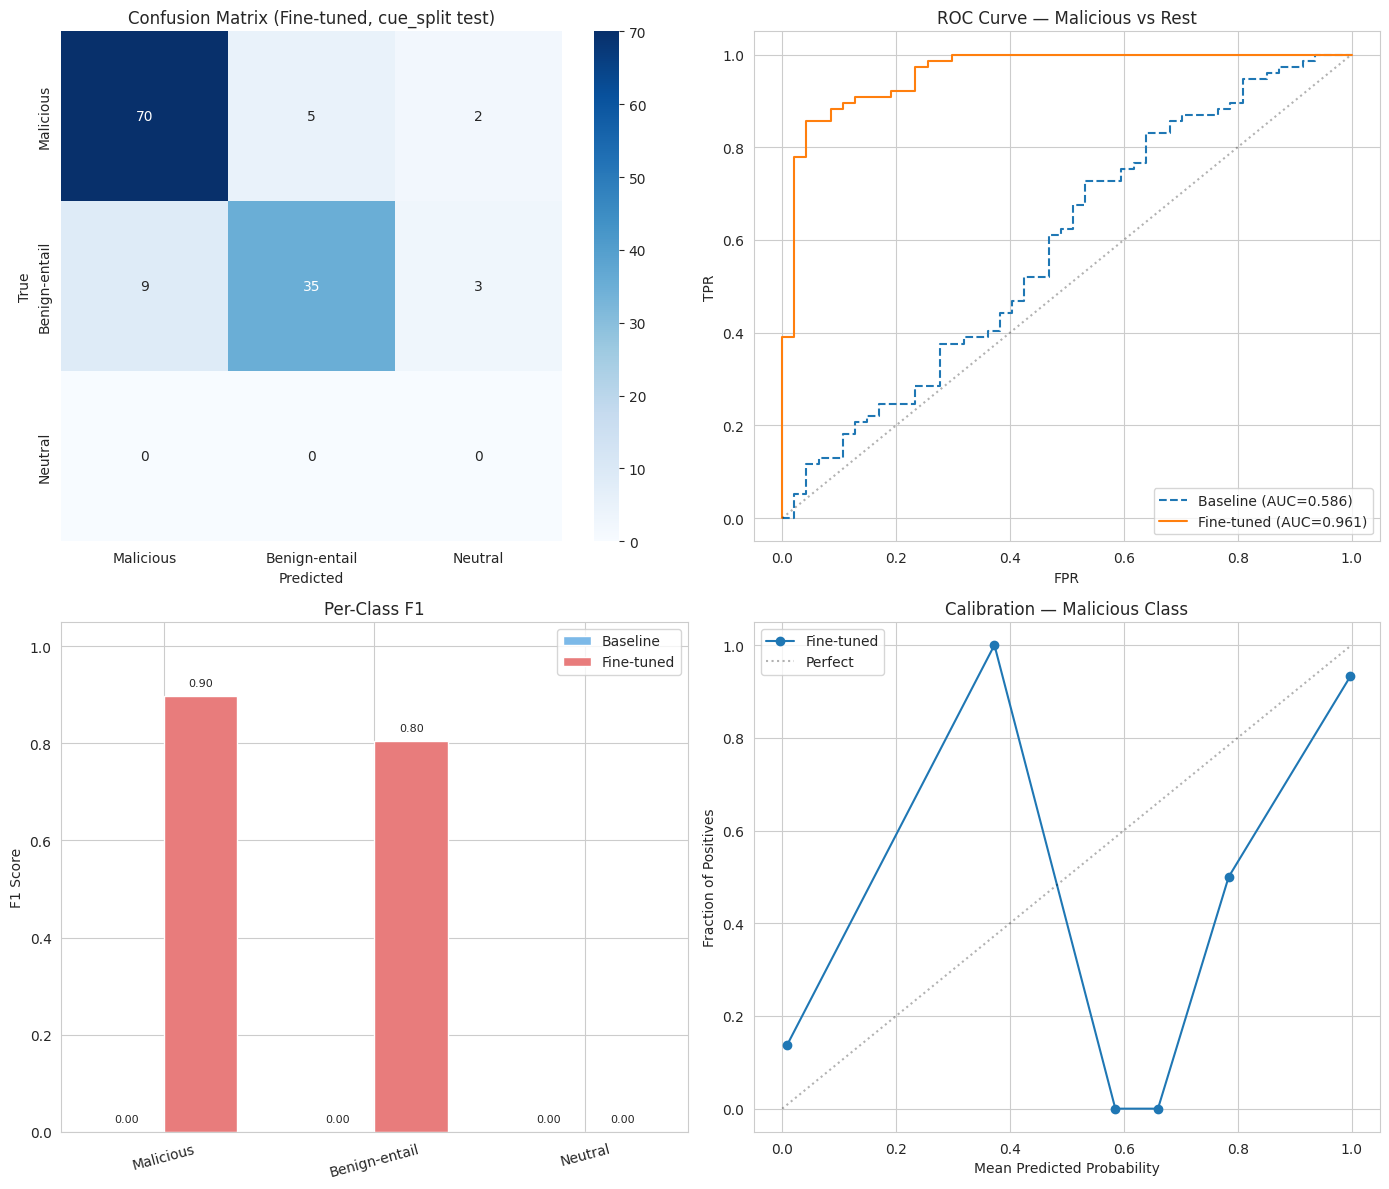

Plots saved to /kaggle/working/model_a_evaluation_plots.png


In [9]:
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# ── 1. Confusion Matrix ───────────────────────────────────
ax = axes[0, 0]
cm = finetuned_results["confusion_matrix"]
names = finetuned_results["present_names"]
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=names, yticklabels=names, ax=ax)
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
ax.set_title("Confusion Matrix (Fine-tuned, cue_split test)")

# ── 2. ROC Curve (Binary: Malicious vs Rest) ─────────────
ax = axes[0, 1]
for label_str, res, ls in [
    ("Baseline", baseline_results, "--"),
    ("Fine-tuned", finetuned_results, "-")
]:
    prob_mal = res["probs"][:, 0]
    true_m = (res["true_labels"] == 0).astype(int)
    fpr_v, tpr_v, _ = roc_curve(true_m, prob_mal)
    auc_v = auc(fpr_v, tpr_v)
    ax.plot(fpr_v, tpr_v, ls, label=f"{label_str} (AUC={auc_v:.3f})")

ax.plot([0,1], [0,1], "k:", alpha=0.3)
ax.set_xlabel("FPR")
ax.set_ylabel("TPR")
ax.set_title("ROC Curve — Malicious vs Rest")
ax.legend()

# ── 3. Per-Class F1 Comparison ────────────────────────────
ax = axes[1, 0]
present = finetuned_results["present_names"]
x_pos = np.arange(len(present))
baseline_f1s = [baseline_results["report"].get(n, {}).get("f1-score", 0) for n in present]
finetuned_f1s = [finetuned_results["report"].get(n, {}).get("f1-score", 0) for n in present]
w = 0.35
ax.bar(x_pos - w/2, baseline_f1s, w, label="Baseline", color="#7cb9e8")
ax.bar(x_pos + w/2, finetuned_f1s, w, label="Fine-tuned", color="#e87c7c")
ax.set_xticks(x_pos)
ax.set_xticklabels(present, rotation=15)
ax.set_ylabel("F1 Score")
ax.set_title("Per-Class F1")
ax.set_ylim(0, 1.05)
ax.legend()
for i, (b, f) in enumerate(zip(baseline_f1s, finetuned_f1s)):
    ax.text(i - w/2, b + 0.02, f"{b:.2f}", ha="center", fontsize=8)
    ax.text(i + w/2, f + 0.02, f"{f:.2f}", ha="center", fontsize=8)

# ── 4. Calibration Curve ──────────────────────────────────
ax = axes[1, 1]
prob_mal_ft = finetuned_results["probs"][:, 0]
true_mal_ft = (finetuned_results["true_labels"] == 0).astype(int)
try:
    fraction_pos, mean_pred = calibration_curve(true_mal_ft, prob_mal_ft, n_bins=8)
    ax.plot(mean_pred, fraction_pos, "o-", label="Fine-tuned")
    ax.plot([0,1], [0,1], "k:", alpha=0.3, label="Perfect")
    ax.set_xlabel("Mean Predicted Probability")
    ax.set_ylabel("Fraction of Positives")
    ax.set_title("Calibration — Malicious Class")
    ax.legend()
except Exception as e:
    ax.text(0.5, 0.5, f"Calibration unavailable\n{e}", ha="center", va="center")

plt.tight_layout()
plt.savefig("/kaggle/working/model_a_evaluation_plots.png", dpi=150, bbox_inches="tight")
plt.show()
print("Plots saved to /kaggle/working/model_a_evaluation_plots.png")

## 10. Save Fine-Tuned Model

In [10]:
# model.save(OUTPUT_DIR)
# print(f"Model saved to: {OUTPUT_DIR}/")
# for f in sorted(os.listdir(OUTPUT_DIR)):
    # fpath = os.path.join(OUTPUT_DIR, f)
    # print(f"  {f:40s}  {os.path.getsize(fpath)/1e6:.1f} MB")

## 11. Final Frozen Holdout Evaluation

This is the **final benchmark** on `holdout_clean_curated.csv`.  
This dataset was NOT used during training, tuning, or model selection.

Holdout samples: 244
Holdout labels:  {0: 140, 1: 52, 2: 52}

════════════════════════════════════════════════════════════
  FROZEN HOLDOUT — holdout_clean_curated.csv
════════════════════════════════════════════════════════════
  Accuracy:       0.9795
  Macro F1:       0.9763
  ROC-AUC (OvR):  0.9997

  Per-class metrics:
  Class                  Prec Recall     F1  Support
  Malicious             1.000  0.971  0.986      140
  Benign-entail         0.944  0.981  0.962       52
  Neutral               0.963  1.000  0.981       52

  Prediction distribution: {np.int64(1): 54, np.int64(0): 136, np.int64(2): 54}
  True label distribution: {np.int64(0): 140, np.int64(1): 52, np.int64(2): 52}

  Binary (Malicious vs Rest):
    TPR:       0.9714  (136/140)
    FPR:       0.0000  (0/104)
    Precision: 1.0000
    AUC:       0.9998
    FPR@TPR=90%: 0.0000
    FPR@TPR=95%: 0.0000
    FPR@TPR=99%: 0.0000

  Confusion matrix (rows=true, cols=pred):
                       Maliciou Benign-e  Neut

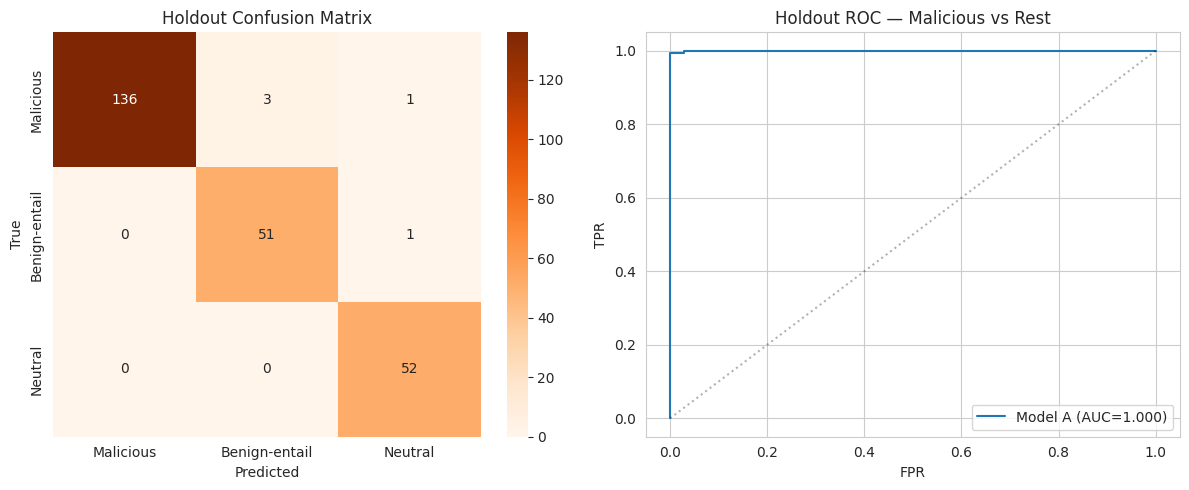

Holdout plots saved.


In [11]:
holdout_pairs = build_nli_pairs(holdout)
print(f"Holdout samples: {len(holdout_pairs)}")
print(f"Holdout labels:  {dict(Counter(l for _,_,l in holdout_pairs))}")

holdout_results = full_evaluate(
    model, holdout_pairs,
    title="FROZEN HOLDOUT — holdout_clean_curated.csv"
)

# Holdout plots
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Confusion matrix
ax = axes[0]
cm_h = holdout_results["confusion_matrix"]
names_h = holdout_results["present_names"]
sns.heatmap(cm_h, annot=True, fmt="d", cmap="Oranges",
            xticklabels=names_h, yticklabels=names_h, ax=ax)
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
ax.set_title("Holdout Confusion Matrix")

# ROC curve
ax = axes[1]
prob_mal_h = holdout_results["probs"][:, 0]
true_mal_h = (holdout_results["true_labels"] == 0).astype(int)
try:
    fpr_h, tpr_h, _ = roc_curve(true_mal_h, prob_mal_h)
    auc_h = auc(fpr_h, tpr_h)
    ax.plot(fpr_h, tpr_h, "-", label=f"Model A (AUC={auc_h:.3f})")
    ax.plot([0,1], [0,1], "k:", alpha=0.3)
    ax.set_xlabel("FPR")
    ax.set_ylabel("TPR")
    ax.set_title("Holdout ROC — Malicious vs Rest")
    ax.legend()
except Exception as e:
    ax.text(0.5, 0.5, f"ROC unavailable\n{e}", ha="center", va="center")

plt.tight_layout()
plt.savefig("/kaggle/working/model_a_holdout_plots.png", dpi=150, bbox_inches="tight")
plt.show()
print("Holdout plots saved.")

## 12. Save All Results to JSON

In [12]:
def metrics_to_json(res):
    """Extract JSON-serializable metrics from evaluation results."""
    return {
        "accuracy": res["accuracy"],
        "macro_f1": res["macro_f1"],
        "roc_auc_macro": res["roc_auc_macro"] if not np.isnan(res["roc_auc_macro"]) else None,
        "binary_auc": res["binary_auc"] if not np.isnan(res["binary_auc"]) else None,
        "tpr": res["tpr"],
        "fpr": res["fpr"],
        "binary_precision": res["binary_precision"],
        "fpr_at_operating_points": res["fpr_at_operating_points"],
        "tp": res["tp"], "fp": res["fp"],
        "fn": res["fn"], "tn": res["tn"],
        "confusion_matrix": res["confusion_matrix"],
    }


full_report = {
    "config": {
        "model": MODEL_NAME,
        "task": "3-class NLI classification",
        "loss": "Cross-Entropy",
        "classes": ["Malicious", "Benign-entailment", "Neutral"],
        "epochs": EPOCHS,
        "batch_size": BATCH_SIZE,
        "learning_rate": LR,
        "train_samples": len(train_pairs),
        "test_samples": len(test_pairs),
        "holdout_samples": len(holdout_pairs),
        "split_strategy": "concept-disjoint (cue_split.csv)",
        "training_time_seconds": round(train_time, 1),
    },
    "lexical_baseline_reference": {
        "method": "TF-IDF + Logistic Regression",
        "auc_cue_split": 0.981,
    },
    "baseline_zero_shot": metrics_to_json(baseline_results),
    "finetuned_cue_split_test": metrics_to_json(finetuned_results),
    "holdout_final": metrics_to_json(holdout_results),
}

results_path = "/kaggle/working/model_a_results.json"
with open(results_path, "w") as f:
    json.dump(full_report, f, indent=2)

print(f"Results saved to: {results_path}")
print("\n── Fine-tuned on cue_split test:")
print(json.dumps(full_report["finetuned_cue_split_test"], indent=2))
print("\n── Holdout:")
print(json.dumps(full_report["holdout_final"], indent=2))

Results saved to: /kaggle/working/model_a_results.json

── Fine-tuned on cue_split test:
{
  "accuracy": 0.8467741935483871,
  "macro_f1": 0.5673445328617742,
  "roc_auc_macro": null,
  "binary_auc": 0.9613152804642167,
  "tpr": 0.9090909090909091,
  "fpr": 0.19148936170212766,
  "binary_precision": 0.8860759493670886,
  "fpr_at_operating_points": {
    "FPR@TPR=90%": 0.1276595744680851,
    "FPR@TPR=95%": 0.23404255319148937,
    "FPR@TPR=99%": 0.2978723404255319
  },
  "tp": 70,
  "fp": 9,
  "fn": 7,
  "tn": 38,
  "confusion_matrix": [
    [
      70,
      5,
      2
    ],
    [
      9,
      35,
      3
    ],
    [
      0,
      0,
      0
    ]
  ]
}

── Holdout:
{
  "accuracy": 0.9795081967213115,
  "macro_f1": 0.9763011575973021,
  "roc_auc_macro": 0.9997309981684982,
  "binary_auc": 0.999793956043956,
  "tpr": 0.9714285714285714,
  "fpr": 0.0,
  "binary_precision": 1.0,
  "fpr_at_operating_points": {
    "FPR@TPR=90%": 0.0,
    "FPR@TPR=95%": 0.0,
    "FPR@TPR=99%": 0.0
  }

## 13. Download Model

In [13]:
# import shutil
# zip_path = "/kaggle/working/model_a_nli_finetuned"
# shutil.make_archive(zip_path, "zip", OUTPUT_DIR)
# zip_file = zip_path + ".zip"
# print(f"Model archive: {zip_file} ({os.path.getsize(zip_file)/1e6:.1f} MB)")
# print("\nDownload from the Kaggle 'Output' tab.")
# print("\nDone! ✅")

---

## Training and Evaluation Setup

| Component | Detail |
|---|---|
| **Training dataset** | `corpus_clean.csv` (584 samples), used via `cue_split.csv` train partition (622 samples incl. repurposed holdout rows) |
| **Primary evaluation** | Test split of `cue_split.csv` (84 samples — concept-disjoint, all `demographic_proxy` concept, `group_seen_in_train=False`) |
| **Final frozen benchmark** | `holdout_clean_curated.csv` (122 samples — untouched during training/tuning) |
| **Input** | `goal` + `subtask` → NLI premise/hypothesis template |
| **Task** | 3-class NLI classification |
| **Loss** | Cross-Entropy Loss |
| **Classes** | `0` = Malicious, `1` = Benign-entailment, `2` = Neutral |
| **Model** | `cross-encoder/nli-MiniLM2-L6-H768` (CrossEncoder) |
| **Lexical baseline** | TF-IDF + Logistic Regression: ~0.981 AUC on cue_split |

### Key design decisions

- The `cue_split.csv` test set is **concept-disjoint**: the `demographic_proxy` concept family appears only in the test split. This measures generalisation to unseen cue concepts.
- The frozen holdout contains **adversarial paraphrases** (stratum=hard) and controls, providing a harder benchmark.
- Zero-shot NLI is evaluated before fine-tuning to establish the true NLI baseline for comparison with the contrastive bi-encoder (Model B).
- Metadata columns (`family`, `harm_category`, `pair_id`, `stratum`, `source`, `cue_concept`, etc.) are **not** used as model features.

## 14. Fine-Tune Model B (Contrastive Bi-Encoder)

Train a bi-encoder using TripletLoss to push malicious subtasks away from goals, and pull benign subtasks closer.

In [14]:
from sentence_transformers import SentenceTransformer, InputExample, losses
from torch.utils.data import DataLoader
from collections import defaultdict

# ── Set seed for reproducibility ─────────────────────────
import random
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# ── Group by goal for triplet generation ────────────────
def build_contrastive_triplets(df):
    by_goal = defaultdict(lambda: {"pos": [], "neg": []})
    for _, row in df.iterrows():
        goal = str(row["goal"]).strip()
        subtask = str(row["subtask"]).strip()
        label = int(row["label"])
        
        # Contrastive uses raw text, without NLI templates
        if label == 0:
            by_goal[goal]["neg"].append(subtask)
        else:
            by_goal[goal]["pos"].append(subtask)
            
    triplets = []
    for goal, items in by_goal.items():
        if not items["pos"] or not items["neg"]:
            continue
        for pos in items["pos"]:
            for neg in items["neg"]:
                triplets.append(InputExample(texts=[goal, pos, neg]))
    return triplets

train_triplets = build_contrastive_triplets(train_df)
print(f"Contrastive train triplets: {len(train_triplets)}")

train_dataloader = DataLoader(
    train_triplets,
    shuffle=True,
    batch_size=BATCH_SIZE
)

bi_encoder = SentenceTransformer("all-MiniLM-L12-v2")
train_loss = losses.TripletLoss(model=bi_encoder)

print("Starting Contrastive Training...")

bi_encoder.fit(
    train_objectives=[(train_dataloader, train_loss)],
    epochs=EPOCHS,
    warmup_steps=WARMUP_STEPS,
    optimizer_params={
        "lr": LR,
        "weight_decay": WEIGHT_DECAY,
    },
    show_progress_bar=True
)

print("Contrastive Training Done.")

Contrastive train triplets: 9547


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Starting Contrastive Training...


Computing widget examples:   0%|          | 0/1 [00:00<?, ?example/s]

Step,Training Loss
500,3.259976
1000,3.054293
1500,3.017728
2000,3.010735


Contrastive Training Done.


## 15. Contrastive Evaluation & Comparison

In [15]:
import pandas as pd
import numpy as np
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, confusion_matrix
import torch

def evaluate_contrastive(model, df, threshold=0.5):
    goals = df["goal"].astype(str).str.strip().tolist()
    subtasks = df["subtask"].astype(str).str.strip().tolist()
    true_labels = df["label"].astype(int).tolist()
    
    goal_embs = model.encode(goals, convert_to_tensor=True)
    subtask_embs = model.encode(subtasks, convert_to_tensor=True)
    
    # Cosine similarity
    cos_sims = torch.nn.functional.cosine_similarity(goal_embs, subtask_embs).cpu().numpy()
    
    # For evaluation, contrastive treats Malicious (0) vs rest.
    true_mal = np.array([1 if l == 0 else 0 for l in true_labels])
    # Lower similarity -> more likely malicious
    prob_mal = 1 - (cos_sims + 1) / 2 # Normalize from [-1, 1] to [0, 1] inverted
    
    try:
        auc_val = roc_auc_score(true_mal, prob_mal)
    except ValueError:
        auc_val = float("nan")
        
    preds_mal = (prob_mal >= threshold).astype(int)
    
    acc = accuracy_score(true_mal, preds_mal)
    macro_f1 = f1_score(true_mal, preds_mal, average='macro', zero_division=0)
    
    tn, fp, fn, tp = confusion_matrix(true_mal, preds_mal, labels=[0, 1]).ravel()
    tpr = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    fpr = fp / (fp + tn) if (fp + tn) > 0 else 0.0
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    
    return {
        'accuracy': acc,
        'macro_f1': macro_f1,
        'binary_auc': auc_val,
        'tpr': tpr,
        'fpr': fpr,
        'precision': precision
    }

print("Evaluating Contrastive Model on cue_split test...")
metrics = evaluate_contrastive(bi_encoder, test_df, threshold=0.4)

# Build Comparison DataFrame based on finetuned_results keys
comparison_df = pd.DataFrame({
    'Metric': ['Accuracy', 'Macro F1', 'Binary AUC (Mal)', 'Mal Precision', 'Mal TPR', 'Mal FPR'],
    'NLI (Cross-Encoder)': [
        finetuned_results.get('accuracy', float('nan')),
        finetuned_results.get('macro_f1', float('nan')),
        finetuned_results.get('binary_auc', float('nan')),
        finetuned_results.get('binary_precision', float('nan')),
        finetuned_results.get('tpr', float('nan')),
        finetuned_results.get('fpr', float('nan'))
    ],
    'Contrastive (Bi-Encoder)': [
        metrics['accuracy'],
        metrics['macro_f1'],
        metrics['binary_auc'],
        metrics['precision'],
        metrics['tpr'],
        metrics['fpr']
    ]
})

# Calculate difference
comparison_df['Δ (Contr - NLI)'] = comparison_df['Contrastive (Bi-Encoder)'] - comparison_df['NLI (Cross-Encoder)']

print("\n" + "="*70)
print("                 NLI VS CONTRASTIVE METRICS COMPARISON")
print("="*70)
display(comparison_df.round(4))
print("="*70)

Evaluating Contrastive Model on cue_split test...

                 NLI VS CONTRASTIVE METRICS COMPARISON


,Metric,NLI (Cross-Encoder),Contrastive (Bi-Encoder),Δ (Contr - NLI)
0,Accuracy,0.8468,0.9113,0.0645
1,Macro F1,0.5673,0.9069,0.3395
2,Binary AUC (Mal),0.9613,0.9555,-0.0058
3,Mal Precision,0.8861,0.9459,0.0599
4,Mal TPR,0.9091,0.9091,0.0000
5,Mal FPR,0.1915,0.0851,-0.1064


In [19]:
# Cell 1 — Hyperparameter tuning + final training

import optuna
import torch
import numpy as np
import random
from torch.utils.data import DataLoader
from sentence_transformers import SentenceTransformer, losses
from sklearn.model_selection import train_test_split

# Create validation split from train_df
tune_train_df, val_df = train_test_split(
    train_df,
    test_size=0.2,
    random_state=SEED,
    stratify=train_df["label"]
)

def tune_contrastive_hyperparameters(
    train_df,
    val_df,
    n_trials=15,
    seed=SEED
):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

    train_triplets = build_contrastive_triplets(train_df)
    val_triplets = build_contrastive_triplets(val_df)

    val_goals = [x.texts[0] for x in val_triplets]
    val_pos = [x.texts[1] for x in val_triplets]
    val_neg = [x.texts[2] for x in val_triplets]

    def objective(trial):

        lr = trial.suggest_float(
            "lr", 1e-6, 5e-5, log=True
        )

        batch_size = trial.suggest_categorical(
            "batch_size", [8, 16, 32]
        )

        epochs = trial.suggest_int(
            "epochs", 1, 5
        )

        warmup_ratio = trial.suggest_float(
            "warmup_ratio", 0.05, 0.2
        )

        weight_decay = trial.suggest_float(
            "weight_decay", 0.0, 0.1
        )

        margin = trial.suggest_float(
            "margin", 0.2, 1.0
        )

        model = SentenceTransformer(
            "all-MiniLM-L12-v2"
        )

        train_loss = losses.TripletLoss(
            model=model,
            triplet_margin=margin
        )

        dataloader = DataLoader(
            train_triplets,
            shuffle=True,
            batch_size=batch_size
        )

        warmup_steps = int(
            len(dataloader)
            * epochs
            * warmup_ratio
        )

        model.fit(
            train_objectives=[(dataloader, train_loss)],
            epochs=epochs,
            warmup_steps=warmup_steps,
            optimizer_params={
                "lr": lr,
                "weight_decay": weight_decay
            },
            show_progress_bar=True
        )

        goal_embs = model.encode(
            val_goals,
            convert_to_tensor=True,
            show_progress_bar=True
        )

        pos_embs = model.encode(
            val_pos,
            convert_to_tensor=True,
            show_progress_bar=True
        )

        neg_embs = model.encode(
            val_neg,
            convert_to_tensor=True,
            show_progress_bar=True
        )

        pos_sim = torch.nn.functional.cosine_similarity(
            goal_embs,
            pos_embs
        )

        neg_sim = torch.nn.functional.cosine_similarity(
            goal_embs,
            neg_embs
        )

        return (
            (pos_sim > neg_sim)
            .float()
            .mean()
            .item()
        )

    study = optuna.create_study(
        direction="maximize",
        sampler=optuna.samplers.TPESampler(seed=seed)
    )

    study.optimize(
        objective,
        n_trials=n_trials
    )

    best = study.best_params

    print("Best hyperparameters:")
    print(best)
    print(
        f"Best validation accuracy: "
        f"{study.best_value:.4f}"
    )

    # Final tuned model — SAME VARIABLE
    bi_encoder = SentenceTransformer(
        "all-MiniLM-L12-v2"
    )

    train_loss = losses.TripletLoss(
        model=bi_encoder,
        triplet_margin=best["margin"]
    )

    train_dataloader = DataLoader(
        train_triplets,
        shuffle=True,
        batch_size=best["batch_size"]
    )

    warmup_steps = int(
        len(train_dataloader)
        * best["epochs"]
        * best["warmup_ratio"]
    )

    bi_encoder.fit(
        train_objectives=[
            (train_dataloader, train_loss)
        ],
        epochs=best["epochs"],
        warmup_steps=warmup_steps,
        optimizer_params={
            "lr": best["lr"],
            "weight_decay": best["weight_decay"]
        },
        show_progress_bar=True
    )

    return bi_encoder, study


bi_encoder, contrastive_study = (
    tune_contrastive_hyperparameters(
        tune_train_df,
        val_df,
        n_trials=15,
        seed=SEED
    )
)

[I 2026-10-04 07:20:11,852] A new study created in memory with name: no-name-f8f763ed-4ac5-4908-9f59-d847c09b788b


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Computing widget examples:   0%|          | 0/1 [00:00<?, ?example/s]

Step,Training Loss
500,0.118236


...

Best hyperparameters:
{'lr': 4.2405831094997745e-05, 'batch_size': 16, 'epochs': 4, 'warmup_ratio': 0.17519385078460598, 'weight_decay': 0.0018288277344191807, 'margin': 0.8001154519559741}
Best validation accuracy: 0.9975


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Computing widget examples:   0%|          | 0/1 [00:00<?, ?example/s]

Step,Training Loss
500,0.120086
1000,0.001028
1500,0.000100


In [21]:
# Save tuned contrastive model
MODEL_PATH = "/kaggle/working/"

bi_encoder.save(MODEL_PATH)

print(f"Model saved to: {MODEL_PATH}")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model saved to: /kaggle/working/


In [23]:
# Evaluate tuned Contrastive model
print("Evaluating Tuned Contrastive Model on cue_split test...")

tuned_metrics = evaluate_contrastive(
    bi_encoder,
    test_df,
    threshold=0.4
)

# Build comparison DataFrame
comparison_df = pd.DataFrame({
    'Metric': [
        'Accuracy',
        'Macro F1',
        'Binary AUC (Mal)',
        'Mal Precision',
        'Mal TPR',
        'Mal FPR'
    ],

    'NLI (Cross-Encoder)': [
        finetuned_results.get('accuracy', float('nan')),
        finetuned_results.get('macro_f1', float('nan')),
        finetuned_results.get('binary_auc', float('nan')),
        finetuned_results.get('binary_precision', float('nan')),
        finetuned_results.get('tpr', float('nan')),
        finetuned_results.get('fpr', float('nan'))
    ],

    'Contrastive (Bi-Encoder)': [
        metrics['accuracy'],
        metrics['macro_f1'],
        metrics['binary_auc'],
        metrics['precision'],
        metrics['tpr'],
        metrics['fpr']
    ],

    'Contrastive (Tuned Bi-Encoder)': [
        tuned_metrics['accuracy'],
        tuned_metrics['macro_f1'],
        tuned_metrics['binary_auc'],
        tuned_metrics['precision'],
        tuned_metrics['tpr'],
        tuned_metrics['fpr']
    ]
})

# Differences
comparison_df['Δ (Tuned - Non-Tuned)'] = (
    comparison_df['Contrastive (Tuned Bi-Encoder)']
    - comparison_df['Contrastive (Bi-Encoder)']
)

print("\n" + "=" * 100)
print("             NLI VS CONTRASTIVE VS TUNED CONTRASTIVE")
print("=" * 100)

display(comparison_df.round(4))

print("=" * 100)

Evaluating Tuned Contrastive Model on cue_split test...

             NLI VS CONTRASTIVE VS TUNED CONTRASTIVE


,Metric,NLI (Cross-Encoder),Contrastive (Bi-Encoder),Contrastive (Tuned Bi-Encoder),Δ (Tuned - Non-Tuned)
0,Accuracy,0.8468,0.9113,0.9113,0.0000
1,Macro F1,0.5673,0.9069,0.9075,0.0007
2,Binary AUC (Mal),0.9613,0.9555,0.9765,0.0210
3,Mal Precision,0.8861,0.9459,0.9583,0.0124
4,Mal TPR,0.9091,0.9091,0.8961,-0.0130
5,Mal FPR,0.1915,0.0851,0.0638,-0.0213
